# Custom Linear Regression (GD-based)

### Libraries and constants

In [1]:
from collections.abc import Callable, Generator
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- CONSTANTS ---
RANDOM_SEED = 42
TARGET_NAME = 'price'

# initial weight boundaries
INITIAL_WEIGHT_LOWER_BND = 1e-6
INITIAL_WEIGHT_UPPER_BND = 1e-5

### Data import

In [3]:
df_train = pd.read_csv(Path('data') / '3 train_post_EDA.csv')
df_test = pd.read_csv(Path('data') / '3 test_post_EDA.csv')

display(df_train.head())
display(df_test.head())

,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


### Custom functions for GD + formula derivation

In [4]:
# custom implementation of sm.add_constant()
def add_np_ones_col(matrix: np.ndarray):
    np_ones = np.ones((matrix.shape[0], 1))
    return np.concatenate((np_ones, matrix), axis=1)

# напишіть функцію гіпотези лінійної регресії у векторному вигляді
def linear_forward_pass(features_matrix: np.ndarray, weights_col: np.ndarray):
    return features_matrix @ weights_col

# створіть функцію для обчислення функції втрат у векторному вигляді
def mse_loss(predictions: np.ndarray, ground_truth: np.ndarray):
    return (1/2) * np.sum((predictions - ground_truth)**2)/len(predictions)

def r2_score_custom(predictions: np.ndarray, ground_truth: np.ndarray):
    # 1. Total variation: how much the actual data spreads around its own mean
    var_mean = np.sum((ground_truth - np.mean(ground_truth)) ** 2)

    # 2. Residual variation: how much the actual data spreads around the regression line
    var_line = np.sum((ground_truth - predictions) ** 2)

    # if we only have 1 or less samples, R2 doesn't make sense
    if len(predictions) <= 1:
        return 0.0
    return 1 - (var_line / var_mean)

> Assuming our loss function being minimized is $MSE$:
> $$J(w) = \frac{1}{2n} * \sum_{i=1}^n{(\hat y_i-y_i)^2}, \text{where}$$
> $\bullet$ $\frac{1}{2}$ is a coefficient to cancel out the future derivative's factor of 2. Given deep networks, by cancelling out $\frac{1}{2} \cdot \frac{2}{1}$, we eliminate billions of additional multiplications + omit dealing with numbers twice as huge, which helps the optimization converge faster. Without it, we <u>would</u> also have to cut our learning rate in half, and it would still be less efficient anyway. We will need to multiple our MSE by 2 for the report though to account for this convenience. \
> $\bullet$ $n$: number of samples, $\frac{1}{n}$ makes it "error per point", hence the name (MEAN squared error) \
> $\bullet$ $\hat y_i$: $i$-th prediction, **or in other words**: $\hat y_i = w_0 + \sum_{i=1}^n{w_i x_i}$ (forward pass) \
> $\bullet$ $y_i$: $i$-th ground truth
> 
> The final goal is to find weights where the error is minimal. Then, we need to know the rate of change between loss and weights. Now, in order to find the rate of change of our <u>loss</u> with respect to <u>weights</u> using chain rule, we need to find the partial derivative such as:
> $$J(w) = \frac{\partial J(w)}{\partial w}=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{(\hat y_i-y_i)^2}]}{\partial w}$$
> Substitute $\hat y_i$ for the forward pass where the variable $w$ is explicitly present in order to differentiate with respect to it and simplify:
>$$\begin{gather}
J(w)=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{\left[(w_ix_i+w_0)-y_i\right]^2}]}{\partial w}=\frac{1}{2n}\sum_{i=1}^n{\underbrace{2(w_ix_i+w_0-y_i)}_{\text{outer derivative}} \cdot \underbrace{\frac{\partial(w_ix_i+w_0-y_i)}{\partial w_i}}_{\text{inner derivative (chain rule)}}} \\ \\
\text{Factor out 2, evaluate the inner derivative, then simplify:} \\
\frac{2}{2n}\sum_{i=1}^n{(w_ix_i+w_0-y_i)(x_i+0-0)}=\frac{1}{n}\sum_{i=1}^n{x_i(w_ix_i+w_0-y_i)} \\ \\
\text{Substitute back:} \\
\nabla J(w) = \frac{1}{n}\sum_{i=1}^n{x_i(\hat y_i-y_i)}
\end{gather}$$
> In order to vectorize it, we need to transpose to align the $i$-th error with the $i$-th feature across all samples (in order for the shapes to allow multiplication):
> $$\nabla J(w) = \frac{1}{n}X^T(\hat y-y)$$

In [5]:
# derivative of MSE loss
def mse_loss_der(features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    n = len(predictions)
    return (1/n) * features @ (predictions - ground_truth)

# реалізуйте один крок градієнтного спуску
def grad(lr: float, loss_der: Callable, features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    return lr * loss_der(features, predictions, ground_truth)

In [6]:
def cross_validation(n_folds: int, data: np.ndarray, target: np.ndarray) -> Generator[tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Performs K-fold cross-validation by splitting data sequentially into train and validation sets.

    Args:
        n_folds (int): determines the equal parts to split the dataset into (1 part will be used for validation and n_fold-1 parts for training)
        data (np.ndarray): 2D array with independent features
        target (np.ndarray): 1D target

    Yields:
        A tuple of four NumPy arrays containing:
            - train_features: Features for training.
            - val_features: Features for validation.
            - train_target: Targets for training.
            - val_target: Targets for validation.

    """
    len_features = len(data)

    # For simplicity: enforce strict division to ensure all validation folds are identical in size
    if len_features % n_folds != 0:
        err = f"Can't divide {len_features} by {n_folds} evenly. Please, change 'n_folds' or trim the data"
        raise ValueError(err)

    # Calculate fixed sample capacity per individual fold
    samples_per_fold = len_features // n_folds

    # Sequentially shift the validation window across the entire dataset
    for i in range(n_folds):
        # Calculate boundaries for the current validation slice
        val_start_idx = i*samples_per_fold
        val_end_idx = i*samples_per_fold+samples_per_fold

        # Extract validation subset based on the active index window
        val_target = target[val_start_idx:val_end_idx]
        val_features = data[val_start_idx:val_end_idx]

        # Combine all data outside the validation window to create the training subset
        train_target = np.concatenate((target[:val_start_idx], target[val_end_idx:]), axis=0)
        train_features = np.concatenate((data[:val_start_idx], data[val_end_idx:]), axis=0)

        yield train_features, val_features, train_target, val_target

In [ ]:
def train_and_validate_fold(
        lr: float,
        epochs: int,
        batch_size: int,
        x_train: np.ndarray,
        y_train: np.ndarray,
        x_val: np.ndarray,
        y_val: np.ndarray,
        w_init: np.ndarray,
        verbose: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains a linear model using gradient descent on a single cross-validation fold in batches.

    Tracks MSE and R2 metrics across both training and validation sets for every epoch to allow for training progress monitoring and overfitting diagnostics.

    Args:
        lr: The learning rate multiplier for gradient updates.
        epochs: Total number of iterations to train the model over.
        batch_size: how many chunks to split the validation data into and update weights per epoch
        x_train: 2D array of training features.
        y_train: 1D array of training target labels.
        x_val: 2D array of validation features.
        y_val: 1D array of validation target labels.
        w_init: 1D array containing the initial model weights.
        verbose: If True, prints final-epoch metrics to stdout. Defaults to True.

    Returns:
        A tuple of five NumPy arrays:
            - w: The final trained weight vector.
            - train_mses: History of training Mean Squared Error per epoch.
            - train_r2s: History of training R-squared scores per epoch.
            - val_mses: History of validation Mean Squared Error per epoch.
            - val_r2s: History of validation R-squared scores per epoch.

    """
    sample_size = len(x_train)

    # Track historical metrics over the training lifecycle
    train_mses, train_r2s = [], []
    val_mses, val_r2s = [], []

    # Prevent side-effects by copying the initial weights array
    w = w_init.copy()

    for epoch in range(epochs):
        for i in range(0, sample_size, batch_size):
            x_train_batch = x_train[i : i + batch_size]
            y_train_batch = y_train[i : i + batch_size]

            # Forward pass & weight update on whatever rows are in this batch
            y_hat_train_batch = linear_forward_pass(x_train_batch, w)
            gradients = grad(lr, mse_loss_der, x_train_batch.T, y_hat_train_batch, y_train_batch)
            w = w - gradients

        # --- Outer Loop Checkpoint: Record Metrics ONCE per Epoch ---
        # 1. Evaluate on the entire training fold
        y_hat_train_full = linear_forward_pass(x_train, w)
        t_mse = mse_loss(y_hat_train_full, y_train)
        train_mses.append(t_mse)
        train_r2s.append(r2_score_custom(y_hat_train_full, y_train))

        # 2. Evaluate on the entire validation fold
        y_hat_val = linear_forward_pass(x_val, w)
        v_mse = mse_loss(y_hat_val, y_val)
        val_mses.append(v_mse)
        val_r2s.append(r2_score_custom(y_hat_val, y_val))

    # 4. Print the final epoch's performance to see how the model finished
    if verbose:
        print(f"(train final epoch) MSE = {train_mses[-1]}")
        print(f"(train final epoch) RMSE = {np.sqrt(train_mses[-1])}")
        print(f"(train final epoch) R2 = {train_r2s[-1]}")
        print()
        print(f"(validation final epoch) MSE = {val_mses[-1]}")
        print(f"(validation final epoch) RMSE = {np.sqrt(val_mses[-1])}")
        print(f"(validation final epoch) R2 = {val_r2s[-1]}")
        print()

    return w, np.array(train_mses), np.array(train_r2s), np.array(val_mses), np.array(val_r2s)

### Data preparation

In [ ]:
X_train, y_train = df_train.drop(columns=[TARGET_NAME]), df_train[TARGET_NAME]
X_test, y_test = df_test.drop(columns=[TARGET_NAME]), df_test[TARGET_NAME]
X_train = add_np_ones_col(X_train)

# init the weights
rng = np.random.default_rng(seed=RANDOM_SEED)
w_init = rng.uniform(low=INITIAL_WEIGHT_LOWER_BND, high=INITIAL_WEIGHT_UPPER_BND, size=(X_train.shape[1], 1))

### Cross-validation to tune the hyperparameters + address under-/overfitting

In [9]:
LR = 0.1        # how large of a step the gradient descent algorithm takes when adjusting the weights
N_FOLDS = 7     # divide the train dataset into 7 parts (i.e., 406 samples / 7 folds = 58 samples). 6 parts (every time, 348 samples are used for training and 58 for validation)
EPOCHS = 50     # how many times to look at the 348 samples to learn the weights
BATCH_SIZE = 11 # how many chunks to split the validation data into and update weights per epoch

# Initialize structures to hold history profiles for each fold
fold_train_mses, fold_train_r2s = [], []
fold_val_mses, fold_val_r2s = [], []

# --- Cross-Validation Execution ---
for i, (train_features, val_features, train_target, val_target) in enumerate(cross_validation(n_folds=N_FOLDS, data=X_train, target=y_train.to_numpy().reshape(-1, 1))):
    print(f"Processing Fold {i+1}/{N_FOLDS}...")

    # do not update weights during cross-validation
    _, t_mse, t_r2, v_mse, v_r2 = train_and_validate_fold(LR, EPOCHS, BATCH_SIZE, train_features, train_target, val_features, val_target, w_init, verbose=True)

    fold_train_mses.append(t_mse)
    fold_train_r2s.append(t_r2)
    fold_val_mses.append(v_mse)
    fold_val_r2s.append(v_r2)

print("----- Cross-Validation Finished -----")
print(f"{N_FOLDS} times the model performed {EPOCHS} cycles to train on {len(train_features)} train samples while validating on {len(val_features)} validation samples")

# --- Mathematical Matrix Averaging Across Folds ---
# Converts lists of 5 arrays into 2D matrices of shape (5, 1000), then takes mean along vertical axis
avg_train_loss = np.mean(np.array(fold_train_mses), axis=0)
avg_val_loss = np.mean(np.array(fold_val_mses), axis=0)
avg_train_r2 = np.mean(np.array(fold_train_r2s), axis=0)
avg_val_r2 = np.mean(np.array(fold_val_r2s), axis=0)

Processing Fold 1/7...
(train final epoch) MSE = 0.025165940212988385
(train final epoch) RMSE = 0.1586377641452009
(train final epoch) R2 = 0.5703226078022383

(validation final epoch) MSE = 0.030276653951217453
(validation final epoch) RMSE = 0.17400187916001786
(validation final epoch) R2 = 0.49093513946768197

Processing Fold 2/7...
(train final epoch) MSE = 0.025914802820349234
(train final epoch) RMSE = 0.16098075295000094
(train final epoch) R2 = 0.5771324749008903

(validation final epoch) MSE = 0.025640436410570573
(validation final epoch) RMSE = 0.16012631392301072
(validation final epoch) R2 = 0.4213695776827697

Processing Fold 3/7...
(train final epoch) MSE = 0.025653089638293193
(train final epoch) RMSE = 0.16016581919464962
(train final epoch) R2 = 0.5677240051566611

(validation final epoch) MSE = 0.027822978353934432
(validation final epoch) RMSE = 0.16680221327648634
(validation final epoch) R2 = 0.4983305368533294

Processing Fold 4/7...
(train final epoch) MSE = 0.0

Take the best epoch (based on smallest MSE and save its hyperparameters)

In [ ]:
best_v_mse = np.inf
best_option = {}

best_idx = np.argmin(avg_val_loss)
best_option = {
'lr': LR,
'n_folds': N_FOLDS,
'epoch': best_idx + 1,
'batch_size': BATCH_SIZE,
'valid_MSE': f"{2*avg_val_loss[best_idx]:.4f}",             # multiplied by 2 to account for the 1/2 factor in MSE
'valid_RMSE': f"{np.sqrt(2*avg_val_loss[best_idx]):.4f}",   # multiplied by 2 to account for the 1/2 factor in MSE
'valid_R2': f"{avg_val_r2[best_idx]:.4f}",
'train_MSE': f"{avg_train_loss[best_idx]:.4f}",
'train_R2': f"{avg_train_r2[best_idx]:.4f}",
}

print("✅ Optimal Hyperparameter Target (Optimized on Averaged Validation Curve):")
print(f"  • lr:                     {LR}")
print(f"  • n_folds:                {N_FOLDS}")
print(f"  • Best Epoch:             {best_option['epoch']}")
print(f"  • Best batch_size:        {best_option['batch_size']}")
print(f"  • Validation MSE:         {best_option['valid_MSE']}  (Train: {best_option['train_MSE']})")
print(f"  • Validation RMSE:        {best_option['valid_RMSE']}")
print(f"  • Validation R²:          {best_option['valid_R2']}  (Train: {best_option['train_R2']})")

✅ Optimal Hyperparameter Target (Optimized on Averaged Validation Curve):
  • lr:                     0.1
  • n_folds:                7
  • Best Epoch:             21
  • Best batch_size:        11
  • Validation MSE:         0.0525  (Train: 0.0259)
  • Validation RMSE:        0.2292
  • Validation R²:          0.5417  (Train: 0.5609)


Plot the averaged metrics to address convergence

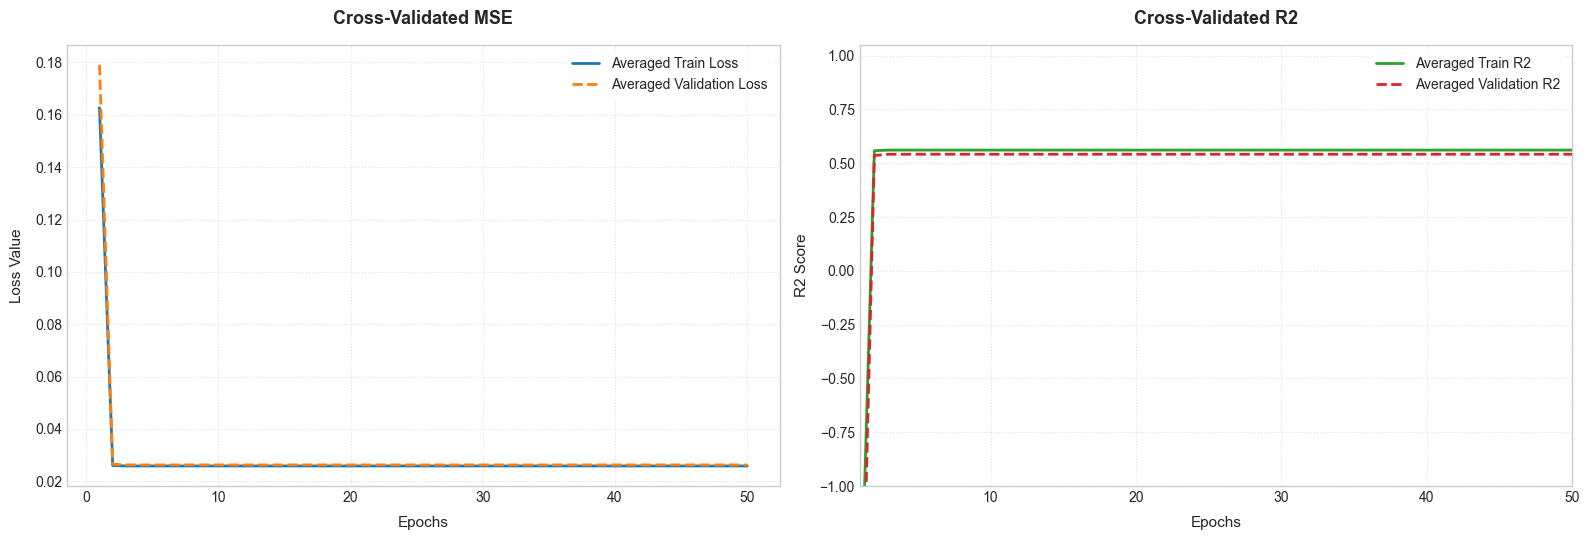

In [11]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Generate side-by-side axes for independent metric evaluation
_, axes = plt.subplots(ncols=2, figsize=(16, 5.5))
epochs_range = np.arange(1, len(avg_train_loss) + 1)

# 1. Plotting Loss Curve Trajectories
axes[0].plot(epochs_range, avg_train_loss, label="Averaged Train Loss", color="#1f77b4", linewidth=2)
axes[0].plot(epochs_range, avg_val_loss, label="Averaged Validation Loss", color="#ff7f0e", linewidth=2, linestyle="--")
axes[0].set_title("Cross-Validated MSE", fontsize=13, fontweight="bold", pad=15)
axes[0].set_xlabel("Epochs", fontsize=11, labelpad=8)
axes[0].set_ylabel("Loss Value", fontsize=11, labelpad=8)

axes[0].legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. Plotting R2 Metric Trajectories
axes[1].plot(epochs_range, avg_train_r2, label="Averaged Train R2", color="#2ca02c", linewidth=2)
axes[1].plot(epochs_range, avg_val_r2, label="Averaged Validation R2", color="#d62728", linewidth=2, linestyle="--")
axes[1].set_title("Cross-Validated R2", fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Epochs", fontsize=11, labelpad=8)
axes[1].set_ylabel("R2 Score", fontsize=11, labelpad=8)

# Force the x-axis to start cleanly at 1 instead of 0
axes[1].set_xlim(left=1, right=len(avg_train_r2))

# Restrict lower bounds for R2 to prevent massive negative jumps from polluting the chart scale
axes[1].set_ylim(bottom=max(-1.0, min(np.min(avg_train_r2), np.min(avg_val_r2)) - 0.1), top=1.05)
axes[1].legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Training the best model

In [12]:
LR = 0.1
N_FOLDS = 7
EPOCHS = 21
BATCH_SIZE = 11

# 2. Train the final model (passing complete training data to both slots)
w_final, _, _, _, _ = train_and_validate_fold(
    lr=LR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    x_train=X_train,
    y_train=y_train.to_numpy().reshape(-1, 1),
    x_val=X_train,
    y_val=y_train.to_numpy().reshape(-1, 1),
    w_init=w_init,
    verbose=True,
)

print("✅ Final weights vector optimized successfully.")
print(w_final)

(train final epoch) MSE = 0.02586471789035536
(train final epoch) RMSE = 0.1608251158568069
(train final epoch) R2 = 0.5611395344584789

(validation final epoch) MSE = 0.02586471789035536
(validation final epoch) RMSE = 0.1608251158568069
(validation final epoch) R2 = 0.5611395344584789

✅ Final weights vector optimized successfully.
[[15.32348094]
 [ 0.17923716]
 [ 0.05636311]
 [ 0.14486393]]


### Test data check

In [ ]:
# Predict
X_test_with_a_constant = add_np_ones_col(X_test)
test_preds_log = linear_forward_pass(X_test_with_a_constant, w_final)
test_preds_usd = np.exp(test_preds_log)

# Evaluate
actual_prices_log = y_test.to_numpy().reshape(-1, 1)
actual_prices_usd = np.exp(y_test.to_numpy().reshape(-1, 1))

test_mse_log = 2*mse_loss(test_preds_log, actual_prices_log) # multiplied by 2 to account for the 1/2 factor in MSE
test_mse_usd = 2*mse_loss(test_preds_usd, actual_prices_usd) # multiplied by 2 to account for the 1/2 factor in MSE

test_rmse_log = np.sqrt(test_mse_log)
test_rmse_usd = np.sqrt(test_mse_usd)

test_r2 = r2_score_custom(test_preds_log, actual_prices_log)

print("\nFINAL TEST SET PERFORMANCE SUMMARY:")
print(f"- MSE:      {test_mse_log:.4f}")
print(f"- RMSE:     {test_rmse_log:.4f} (${test_rmse_usd:,.2f})")
print(f"- R2:       {test_r2:.4f}")

print("\nSample Holdout Comparisons (First 5 Houses):")

# Let's inspect the first 5 entries side-by-side
for i in range(5):
    predicted = test_preds_usd[i][0]
    actual = actual_prices_usd[i][0]
    error = predicted - actual
    print(f"House {i+1}: Predicted: ${predicted:,.2f} | Actual: ${actual:,.2f} | Deviation: ${error:,.2f}")


FINAL TEST SET PERFORMANCE SUMMARY:
- MSE:      0.0654
- RMSE:     0.2557 ($1,337,217.76)
- R2:       0.4296

Sample Holdout Comparisons (First 5 Houses):
House 1: Predicted: $4,305,615.41 | Actual: $5,740,000.00 | Deviation: $-1,434,384.59
House 2: Predicted: $4,680,041.77 | Actual: $6,629,000.00 | Deviation: $-1,948,958.23
House 3: Predicted: $3,380,574.94 | Actual: $3,745,000.00 | Deviation: $-364,425.06
House 4: Predicted: $4,383,545.65 | Actual: $5,810,000.00 | Deviation: $-1,426,454.35
House 5: Predicted: $6,609,966.72 | Actual: $6,293,000.00 | Deviation: $316,966.72


**Conclusion**: The performance on test is noticeably worse than on train. We could try regularization, but given the very limited set of features + weak linearity of the data, it doesn't make sense.